### Modeling Approach: Price-Driven Demand Forecasting

We model weekly unit sales at the **sub-category level** using a simple log-log linear regression.

#### Target Variable
- `log(1 + weekly unit sales)`

#### Feature
- `log(1 + average shelf price)`  
  (We use actual transaction price rather than base price to better capture promotional effects)

#### Methodology
1. Aggregate the data to `sub_category × week` level.
2. Apply `log1p` transformation to both the target (unit sales) and the feature (price).
3. Standardize the feature using `StandardScaler`.
4. Fit a Linear Regression model:
   \[
   \log(1 + \text{Units}) = \beta_0 + \beta_1 \cdot \log(1 + \text{Price}) + \varepsilon
   \]
5. Generate future price forecasts using Prophet.
6. Feed the Prophet price forecasts into the trained linear model to obtain unit sales forecasts.
7. Inverse-transform the predictions using `expm1` to return to the original unit sales scale.

#### Interpretation
- The coefficient \(\beta_1\) represents the **price elasticity of demand**.
- A value of \(\beta_1 = -1.5\), for example, implies that a 1% increase in price is associated with an approximately 1.5% decrease in unit sales (holding other factors constant).

#### Limitations
- The model currently uses only price as a predictor.
- It does not yet account for promotional flags (`feature`, `display`, `tpr_only`), store traffic, or seasonality beyond what is captured indirectly through price.
- Results should be interpreted as directional rather than precise forecasts.

In [645]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import logging
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, ElasticNet

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.FileHandler("data_pipeline.log"), logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

In [646]:
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [647]:
def read_data(path):
    if path.endswith((".xls", ".xlsx")):
        df = pd.read_excel(path)
    elif path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file extension at path: {path}")
    if not df.empty:
        print(f"Loaded {len(df)} rows")
    else:
        print(f"Empty dataframe found at path {path}")

    return df

def check_missing_weeks(df):
    df = df.copy()
    df.rename(columns=lambda x: str(x).strip().lower(), inplace=True)
    df["time"]=pd.to_datetime(df["week_end_date"],errors='coerce')
    missing_week_mask=df[(df["price"].isna()) | (df["base_price"].isna())].index
    missing_weeks=df.loc[missing_week_mask,"time"].tolist()
    return missing_weeks,df 

def _clean(df):
    df = df.copy()
    df.rename(columns=lambda x: str(x).strip().lower(), inplace=True)

    if missing_weeks is not None:
       logging.info(f'Missing weeks found...')
       logging.info(f'Replacing null values with forward fill')
       df=df.ffill()
       
    logging.info(f'Cleaning Base Price and Price cols...')
    df=df[(df["base_price"]>0) & (df["price"]>0)]
    logging.info(f'Cleaned dataframe with {len(df)} rows')

    return df

In [648]:
df=read_data('../trans_new.csv')
missing_weeks,df=check_missing_weeks(df)
df=_clean(df)

2026-09-03 12:17:06,099 - INFO - Missing weeks found...
2026-09-03 12:17:06,100 - INFO - Replacing null values with forward fill


Loaded 538643 rows


2026-09-03 12:17:06,282 - INFO - Cleaning Base Price and Price cols...
2026-09-03 12:17:06,365 - INFO - Cleaned dataframe with 538642 rows


In [649]:
logging.info(f'Available columns are {df.columns}')

2026-09-03 12:17:06,389 - INFO - Available columns are Index(['week_end_date', 'store_id', 'upc', 'units', 'visits', 'hhs', 'spend',
       'price', 'base_price', 'feature', 'display', 'tpr_only', 'description',
       'manufacturer', 'category', 'sub_category', 'product_size',
       'store_name', 'address_city_name', 'address_state_prov_code',
       'msa_code', 'seg_value_name', 'parking_space_qty',
       'sales_area_size_num', 'avg_weekly_baskets', 'time'],
      dtype='str')


In [650]:
df["sub_category"].unique()

<StringArray>
[                   'PRETZELS',    'MOUTHWASHES (ANTISEPTIC)',
           'ALL FAMILY CEREAL',                'ADULT CEREAL',
               'PIZZA/PREMIUM',                 'KIDS CEREAL',
 'MOUTHWASH/RINSES AND SPRAYS']
Length: 7, dtype: str

In [651]:
grp=df.groupby(["sub_category","time"]).agg(agg_unit_sales=('units','sum'),
                                        agg_dollar_sales=('spend','sum'),
                                        agg_price=('price','mean')).reset_index()
grp

,sub_category,time,agg_unit_sales,agg_dollar_sales,agg_price
0,ADULT CEREAL,2009-01-14,2195,3996.67,1.806329
1,ADULT CEREAL,2009-01-21,2044,3796.36,1.853924
2,ADULT CEREAL,2009-01-28,2106,3910.53,1.850759
3,ADULT CEREAL,2009-02-04,2370,4404.07,1.851772
4,ADULT CEREAL,2009-02-11,2237,4026.03,1.797692
...,...,...,...,...,...
1087,PRETZELS,2011-12-07,17903,34287.20,2.271135
1088,PRETZELS,2011-12-14,19765,38672.06,2.391863
1089,PRETZELS,2011-12-21,22774,44313.59,2.389222
1090,PRETZELS,2011-12-28,19613,38407.18,2.392700


In [652]:
sc = 'ALL FAMILY CEREAL'

In [653]:
forecast_list = ["agg_price", "agg_dollar_sales", "agg_unit_sales"]

models = {}
forecasts = {}

for var in forecast_list:

    data = grp[grp["sub_category"] == sc].copy()
    data = data.rename(columns={"time": "ds", var: "y"})

    cols_to_drop = ["sub_category"] + [x for x in forecast_list if x != var]
    data = data.drop(columns=cols_to_drop, errors="ignore")

    models[var]=Prophet(yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative")
    models[var].fit(data)

    future = models[var].make_future_dataframe(periods=156, freq="W")
    forecasts[var] = models[var].predict(future)


2026-09-03 12:17:06,597 - INFO - Chain [1] start processing
2026-09-03 12:17:06,637 - INFO - Chain [1] done processing
2026-09-03 12:17:07,355 - INFO - Chain [1] start processing
2026-09-03 12:17:07,374 - INFO - Chain [1] done processing
2026-09-03 12:17:07,460 - INFO - Chain [1] start processing
2026-09-03 12:17:07,484 - INFO - Chain [1] done processing


In [654]:
forecast=pd.DataFrame(forecasts["agg_unit_sales"])[["ds","yhat"]].tail(156)
forecast["year"]=forecast["ds"].dt.year
forecast.pivot_table(
    index="year", values="yhat", aggfunc="sum"
).round(4)

,yhat
year,
2012,994481.7369
2013,991489.2148
2014,988505.4365


In [655]:
df.columns

Index(['week_end_date', 'store_id', 'upc', 'units', 'visits', 'hhs', 'spend',
       'price', 'base_price', 'feature', 'display', 'tpr_only', 'description',
       'manufacturer', 'category', 'sub_category', 'product_size',
       'store_name', 'address_city_name', 'address_state_prov_code',
       'msa_code', 'seg_value_name', 'parking_space_qty',
       'sales_area_size_num', 'avg_weekly_baskets', 'time'],
      dtype='str')

In [656]:
def train_linear_model(df, group_cols, sub_category):
    df = df.copy()
    grp = (
        df.groupby(group_cols)
        .agg(
            agg_unit_sales=("units", "sum"),
            agg_dollar_sales=("spend", "sum"),
            agg_price=("price", "mean"), #price is promo price. Prev, I used non-promo base_price only
        )
        .reset_index()
    )

    grp["agg_price"]=np.log1p(grp["agg_price"])
    grp["agg_unit_sales"]=np.log1p(grp["agg_unit_sales"])

    data = grp[grp["sub_category"] == sub_category].copy()

    X = data[["agg_price"]]
    y = data["agg_unit_sales"]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    model = LinearRegression() #ElasticNet(alpha=1,l1_ratio=0.75)
    model.fit(X_scaled, y)

    return model, {"slope": model.coef_, "intercept": model.intercept_},scaler


trained_lr_model, coef_dict,scaler = train_linear_model(
    df=df, group_cols=["sub_category", "time"], sub_category=sc
)

In [657]:
elasticity = trained_lr_model.coef_[0]
logging.info(f"Price elasticity coefficient: {elasticity:.4f}")

2026-09-03 12:17:07,906 - INFO - Price elasticity coefficient: -0.1395


In [658]:
log_agg_price_forecast=np.log1p(forecasts["agg_price"]["yhat"])
forecast_input = pd.DataFrame(
    {
        "agg_price": log_agg_price_forecast
    }
)
forecast_input=pd.DataFrame(scaler.transform(forecast_input), columns=forecast_input.columns)
forecast_input

,agg_price
0,-0.321777
1,0.511016
2,0.698768
3,-0.136230
4,-1.616016
...,...
307,3.116647
308,3.496399
309,3.778745
310,3.683172


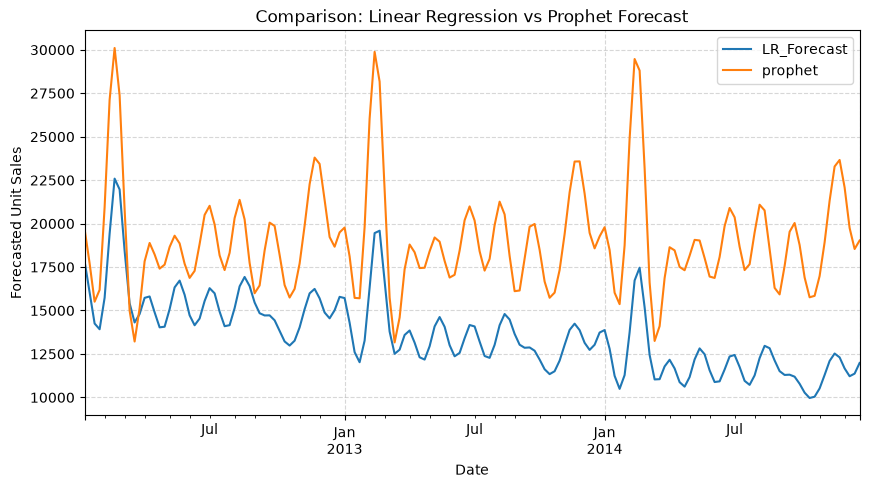

In [659]:
unit_sales_forecast=pd.DataFrame(trained_lr_model.predict(forecast_input),columns=['LR_Forecast'])
unit_sales_forecast["LR_Forecast"]=np.expm1(unit_sales_forecast["LR_Forecast"])
unit_sales_forecast["prophet"]=forecasts["agg_unit_sales"]["yhat"]
unit_sales_forecast["time"]=forecasts["agg_unit_sales"]["ds"]
unit_sales_forecast.tail(156).set_index("time")[["LR_Forecast", "prophet"]].plot(
    kind="line", figsize=(10, 5)
)


plt.title("Comparison: Linear Regression vs Prophet Forecast")
plt.ylabel("Forecasted Unit Sales")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.5)  
plt.show()


In [660]:
unit_sales_forecast["year"]=unit_sales_forecast["time"].dt.year
pivot=unit_sales_forecast.pivot_table(
    index="year", values=["LR_Forecast","prophet"], aggfunc="sum"
).round(4)
pivot["LR_YoY"]=pivot["LR_Forecast"].pct_change()*100
pivot["prophet_YoY"]=pivot["prophet"].pct_change()*100
pivot.round(2)

,LR_Forecast,prophet,LR_YoY,prophet_YoY
year,,,,
2009,1011048.39,1043369.22,NaN,NaN
2010,1020434.16,1001566.51,0.93,-4.01
2011,930607.59,997563.16,-8.80,-0.40
2012,825494.33,1014404.31,-11.30,1.69
2013,705180.94,991489.21,-14.57,-2.26
2014,619063.43,988505.44,-12.21,-0.30


                agg_price  agg_unit_sales
agg_price        1.000000       -0.575606
agg_unit_sales  -0.575606        1.000000


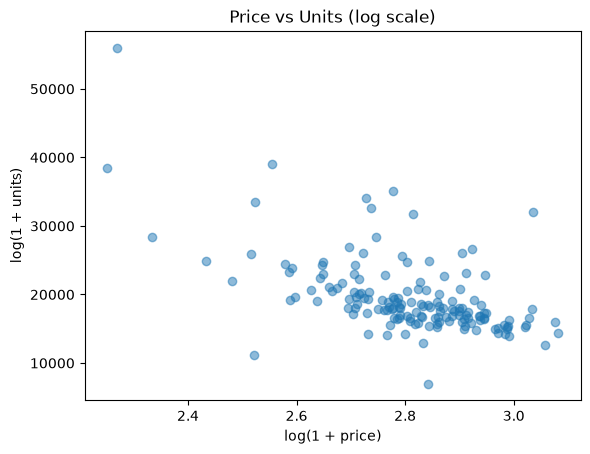

In [661]:
# Check correlation
data=grp[grp["sub_category"]==sc]
print(data[["agg_price", "agg_unit_sales"]].corr())

# Check a simple plot
import matplotlib.pyplot as plt
plt.scatter(data["agg_price"], data["agg_unit_sales"], alpha=0.5)
plt.xlabel("log(1 + price)")
plt.ylabel("log(1 + units)")
plt.title("Price vs Units (log scale)")
plt.show()